# Su Talebi Tahmini Modeli

Bu notebook, `malatya_gunluk_su_tuketimi_20yil.csv` veri seti ile su talebi tahmini için bir model oluşturur. Aşamalar: veri yükleme, ön işleme, özellik mühendisliği, model eğitimi ve değerlendirme.

In [17]:
# Gerekli kütüphaneleri import edelim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

## Su Talebi Tahmini için Birden Fazla Veri Seti

Bu bölümde `malatya_gunluk_su_tuketimi_20yil.csv` ile `malatya_gunluk_yagis_20yil.csv` veri setlerini tarih bazlı birleştirerek model için daha zengin özellikler oluşturacağız.

In [18]:
# Gerekli paketleri yükleyelim
%pip install xgboost lightgbm

# Veri setlerini yükleyelim
df_su = pd.read_csv('malatya_gunluk_su_tuketimi_20yil.csv')
df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')
print(f"Su tüketimi veri seti boyutu: {df_su.shape}")
print(f"Yağış veri seti boyutu: {df_yagis.shape}")

# Tarih sütunlarını standartlaştırıp birleştirelim
def prepare_date(df, label):
    date_cols = [c for c in df.columns if 'tarih' in c.lower() or 'date' in c.lower()]
    if len(date_cols) == 0:
        raise ValueError(f"{label} veri setinde tarih sütunu bulunamadı")
    date_col = date_cols[0]
    df = df.copy()
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    return df

sudf = prepare_date(df_su, 'Su')
yagisdf = prepare_date(df_yagis, 'Yağış')

common_cols = [c for c in yagisdf.columns if c != 'date' and c not in sudf.columns]
merged = sudf.merge(yagisdf[['date'] + common_cols], on='date', how='inner', suffixes=('_su', '_yagis'))
print(f"Birleşik veri seti boyutu: {merged.shape}")

# Modelleme için kullanacağımız ana veri çerçevesi
merged = merged.drop(columns=[c for c in merged.columns if 'tarih' in c.lower() and c != 'date'])
df = merged.copy()
df.head()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Su tüketimi veri seti boyutu: (7305, 4)
Yağış veri seti boyutu: (7305, 5)
Birleşik veri seti boyutu: (7305, 9)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\CASPER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,Ort_Sicaklik,Hafta_Sonu,Su_Tuketimi_m3,date,Karakaya_Yagis_mm,Surgu_Yagis_mm,Sultansuyu_Yagis_mm,Genel_Ortalama_mm
0,-1.7,0,93910,2004-01-01,0.0,0.0,0.0,0.0
1,-1.2,0,96421,2004-01-02,0.0,0.0,0.0,0.0
2,-5.7,1,102581,2004-01-03,0.0,0.0,0.0,0.0
3,0.9,1,103912,2004-01-04,0.0,0.0,0.0,0.0
4,-3.6,0,95013,2004-01-05,0.7,1.2,1.0,1.0


In [19]:
# Veri hakkında hızlı inceleme
print(df.info())
print('\nEksik değerler:\n', df.isnull().sum())
print('\nTemel istatistikler:')
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Ort_Sicaklik         7305 non-null   float64       
 1   Hafta_Sonu           7305 non-null   int64         
 2   Su_Tuketimi_m3       7305 non-null   int64         
 3   date                 7305 non-null   datetime64[ns]
 4   Karakaya_Yagis_mm    7305 non-null   float64       
 5   Surgu_Yagis_mm       7305 non-null   float64       
 6   Sultansuyu_Yagis_mm  7305 non-null   float64       
 7   Genel_Ortalama_mm    7305 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 456.7 KB
None

Eksik değerler:
 Ort_Sicaklik           0
Hafta_Sonu             0
Su_Tuketimi_m3         0
date                   0
Karakaya_Yagis_mm      0
Surgu_Yagis_mm         0
Sultansuyu_Yagis_mm    0
Genel_Ortalama_mm      0
dtype: int64

Temel istatistik

In [20]:
# Tarih sütunu varsa datetime dönüşümü ve ek özellikler

datetime_cols = [c for c in df.columns if 'tarih' in c.lower() or 'date' in c.lower()]
if len(datetime_cols) > 0:
    date_col = datetime_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['weekday'] = df[date_col].dt.weekday
    print(f"Datetime sütunu kullanıldı: {date_col}")
else:
    date_col = None
    print('Tarih sütunu bulunamadı. Modelde sadece sayısal ve kategorik özellikler kullanılacaktır.')

# Hedef sütun tespiti
possible_targets = [c for c in df.columns if 'su' in c.lower() and ('tuketim' in c.lower() or 'talep' in c.lower() or 'miktar' in c.lower())]
if len(possible_targets) > 0:
    target_col = possible_targets[0]
else:
    target_col = df.columns[-1]
    print(f"Tahmin edilecek hedef sütun otomatik seçildi: {target_col}")

print(f"Hedef sütun: {target_col}")

Datetime sütunu kullanıldı: date
Hedef sütun: Su_Tuketimi_m3


In [21]:
# Model eğitiminde kullanılacak sütunları belirleyelim
feature_cols = [c for c in df.columns if c != target_col and c != date_col]
feature_cols = [c for c in feature_cols if c not in datetime_cols]
feature_cols = df[feature_cols].select_dtypes(exclude=['datetime64[ns]']).columns.tolist()
print('Kullanılacak özellikler:', feature_cols)

# Kategorik sütunlar varsa one-hot encode edelim
categorical_cols = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print('One-hot encoding yapılan sütunlar:', categorical_cols)

# Eksik değerleri temizleyelim
initial_shape = df.shape

df = df.dropna(subset=[target_col])
df = df.dropna()
print(f"Eksik değer temizlendikten sonra boyut: {df.shape} (ilk: {initial_shape})")

Kullanılacak özellikler: ['Ort_Sicaklik', 'Hafta_Sonu', 'Karakaya_Yagis_mm', 'Surgu_Yagis_mm', 'Sultansuyu_Yagis_mm', 'Genel_Ortalama_mm', 'year', 'month', 'day', 'weekday']
Eksik değer temizlendikten sonra boyut: (7305, 12) (ilk: (7305, 12))


In [22]:
# Özellik ve hedef verisini ayıralım
X = df[[c for c in df.columns if c != target_col]]
y = df[target_col]

# Kalan datetime sütunları varsa çıkaralım
datetime_cols = X.select_dtypes(include=['datetime64[ns]']).columns.tolist()
if len(datetime_cols) > 0:
    print('Drop edilen datetime sütunları:', datetime_cols)
    X = X.drop(columns=datetime_cols)

# Eğitim/test verisini ayıralım
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

# Ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Drop edilen datetime sütunları: ['date']
Eğitim seti: (5844, 10), Test seti: (1461, 10)


In [23]:
# Modelleri eğitelim
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, n_estimators=100)
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} sonuçları:")
    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")

    print(f"  R2: {r2:.3f}\n")

Linear Regression sonuçları:
  MAE: 4257.778
  RMSE: 5380.128
  R2: 0.958

Random Forest sonuçları:
  MAE: 3275.226
  RMSE: 4117.971
  R2: 0.976

XGBoost sonuçları:
  MAE: 2813.042
  RMSE: 3568.225
  R2: 0.982

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 5844, number of used features: 10
[LightGBM] [Info] Start training from score 151811.938056
LightGBM sonuçları:
  MAE: 2727.533
  RMSE: 3420.091
  R2: 0.983



C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


En iyi model: LightGBM
Model kaydedildi: su_talebi_modeli.joblib


C:\Users\CASPER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


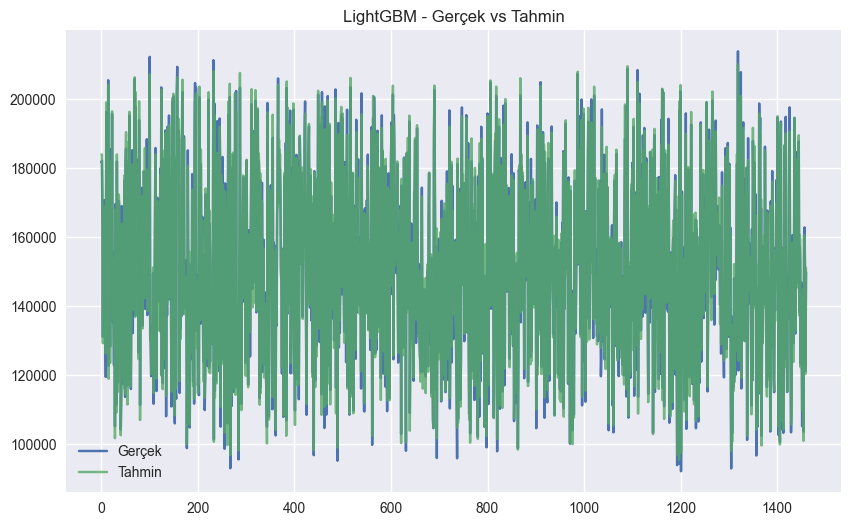

In [24]:
# En iyi modeli seçip kaydedelim
best_model_name = min(results, key=lambda k: results[k]['RMSE'])
best_model = models[best_model_name]
print(f"En iyi model: {best_model_name}")

joblib.dump({'model': best_model, 'scaler': scaler, 'features': X.columns.tolist()}, 'su_talebi_modeli.joblib')
print('Model kaydedildi: su_talebi_modeli.joblib')

# Tahminlerin görselleştirilmesi
best_pred = best_model.predict(X_test_scaled)
plt.figure()
plt.plot(y_test.values, label='Gerçek')
plt.plot(best_pred, label='Tahmin', alpha=0.8)
plt.title(f'{best_model_name} - Gerçek vs Tahmin')
plt.legend()
plt.show()

## Model Performans Karşılaştırma Arayüzü

Bu bölüm, eğitilmiş modellerin performansını interaktif olarak karşılaştırmanızı sağlar. Kullanıcılar, model seçerek MAE, RMSE ve R2 değerlerini görebilir ve hangi modelin daha iyi çalıştığını anlayabilirler.

Dropdown(description='Model:', options=('Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM'), value='L…

Output()

,Değer
MAE,4257.778351
RMSE,5380.127809
R2,0.958313


,MAE,RMSE,R2
Linear Regression,4257.778351,5380.127809,0.958313
Random Forest,3275.225530,4117.971253,0.975578
XGBoost,2813.041504,3568.224629,0.981663
LightGBM,2727.533203,3420.090826,0.983154


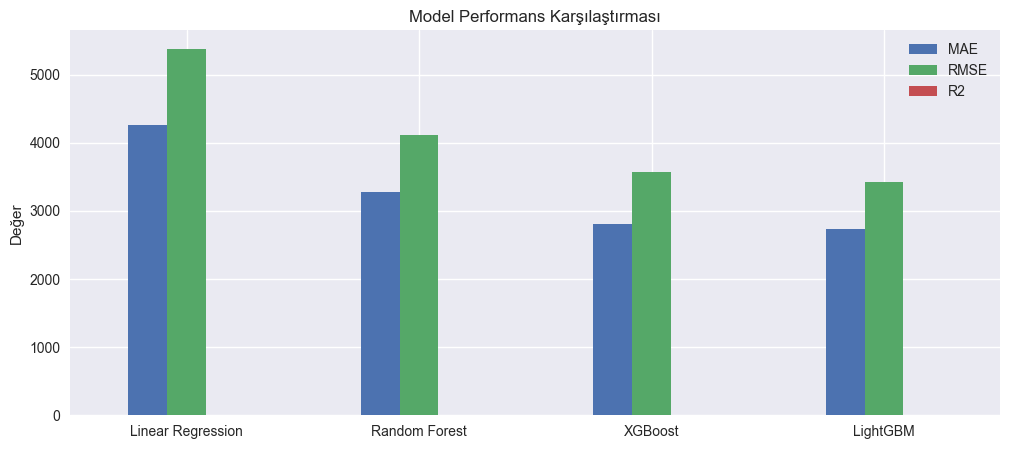

In [ ]:
# Arayüzü oluşturmak için gerekli bileşenler
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML
except ImportError:
    %pip install ipywidgets
    import ipywidgets as widgets
    from IPython.display import display, HTML

# Model sonuçlarını gösteren yardımcı fonksiyon

def show_model_info(model_name):
    if 'results' not in globals():
        print('Önce model eğitim hücresini çalıştırın.')
        return

    info = results[model_name]
    display(HTML(f"<h3>{model_name}</h3>"))
    display(pd.DataFrame.from_dict(info, orient='index', columns=['Değer']))

    if model_name in models:
        model = models[model_name]
        if hasattr(model, 'feature_importances_'):
            fi = pd.Series(model.feature_importances_, index=X.columns)
            fi = fi.sort_values(ascending=False).head(10)
            display(HTML('<b>Özellik önem sıralaması:</b>'))
            display(fi.to_frame('Önem'))
        else:
            display(HTML('<em>Bu model için özellik önem sıralaması kullanılabilir değil.</em>'))


def on_model_change(change):
    if change['name'] == 'value':
        with output:
            output.clear_output()
            show_model_info(change['new'])


model_names = list(results.keys()) if 'results' in globals() else []
if len(model_names) == 0:
    print('Önce model eğitim hücresini çalıştırın ve sonuçları hesaplayın.')
else:
    dropdown = widgets.Dropdown(options=model_names, description='Model:')
    output = widgets.Output()
    dropdown.observe(on_model_change)
    display(dropdown, output)
    show_model_info(model_names[0])

    # Performans karşılaştırma tablosu
    summary_df = pd.DataFrame(results).T
    display(HTML('<h4>Model Performans Karşılaştırması</h4>'))
    display(summary_df)
    summary_df.plot.bar(rot=0, figsize=(12, 5))
    plt.title('Model Performans Karşılaştırması')
    plt.ylabel('Değer')
    plt.show()